In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 4 — Hashtable com colisões e encadeamento

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. Exercício 4 **→ você está aqui**
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.linked_list import SinglyLinkedList

---
# Exercício 4 — Hashtable com colisões e encadeamento

## Enunciado
Implementar `HashTableChained` com `put`/`get`/`delete`/`__len__`, cada bucket
sendo uma **lista encadeada** de pares, com redimensionamento automático por
fator de carga, contagem de comparações dentro dos buckets relacionada a α, e um
cenário adversarial de colisões.

## Implementação — `src/hashtable.py`

**Decisão de projeto 1 — função de hash própria e determinística (FNV-1a 64).**
`hash()` de `str` em CPython é *salgado* por processo (`PYTHONHASHSEED`): a mesma
chave cai em buckets diferentes a cada execução. Com `hash()` embutido, as
contagens mudariam a cada run e o notebook, o PDF e o vídeo mostrariam números
diferentes. Há teste com valor literal — se alguém trocar pelo `hash()` embutido,
a suíte quebra na hora.

**Decisão de projeto 2 — o bucket é a `SinglyLinkedList` do exercício 10.**
`HashBucket` **herda** dela e acrescenta as operações por *chave*. Ganha o nó,
`insert_last` O(1), `_unlink` com manutenção do `tail` e `check_invariants` já
testado. Cada operação faz **uma única travessia**.

In [5]:
from src.hashtable import (DEFAULT_LOAD_FACTOR_THRESHOLD, HashBucket, HashTableChained,
                           KeyNotFoundError, UnsupportedKeyError, bench_adversarial,
                           bench_alpha_vs_comparisons, bench_rehash_amortizado,
                           bench_resizing_keeps_cost_constant, default_hash,
                           find_colliding_keys, fnv1a_64, key_to_bytes)

# o bucket é mesmo uma lista encadeada do ex 10
assert isinstance(HashBucket(), SinglyLinkedList)
print("HashBucket é uma SinglyLinkedList:", isinstance(HashBucket(), SinglyLinkedList))

# determinismo do hash: valores literais
assert fnv1a_64(b"a") == 12638187200555641996        # vetor de teste do FNV-1a
assert default_hash("termo") == 6982619395706773855
print(f'default_hash("termo") = {default_hash("termo")}  (estável entre execuções)')

tabela = HashTableChained()
for i in range(500):
    tabela.put(f"chave-{i}", i * 7)
tabela.check_invariants()
assert len(tabela) == 500
assert tabela.get("chave-42") == 294

# atualização de chave existente NÃO cria duplicata
tabela.put("chave-42", -1)
assert len(tabela) == 500 and tabela.get("chave-42") == -1
assert tabela.delete("chave-42") == -1 and len(tabela) == 499
tabela.check_invariants()
print(f"{tabela!r}  · redimensionamentos: {tabela.resizes}")

HashBucket é uma SinglyLinkedList: True
default_hash("termo") = 6982619395706773855  (estável entre execuções)
HashTableChained(size=499, capacity=1024, alpha=0.487)  · redimensionamentos: 7


In [6]:
alpha = pd.DataFrame(bench_alpha_vs_comparisons(probes=2_000))
mostrar(alpha, ["padrao", "n", "capacidade", "alpha", "comparacoes_por_busca",
                "previsao_teorica", "medido/teorico", "cadeia_maxima"],
        "FATOR DE CARGA × COMPARAÇÕES (capacidade fixa em 64, sem redimensionar)")

FATOR DE CARGA × COMPARAÇÕES (capacidade fixa em 64, sem redimensionar)


,padrao,n,capacidade,alpha,comparacoes_por_busca,previsao_teorica,medido/teorico,cadeia_maxima
0,busca com sucesso,16,64,0.2500,1.3850,1.1250,1.2311,2
1,busca sem sucesso,16,64,0.2500,0.2720,0.2500,1.0880,2
2,busca com sucesso,32,64,0.5000,1.2345,1.2500,0.9876,2
3,busca sem sucesso,32,64,0.5000,0.5420,0.5000,1.0840,2
4,busca com sucesso,64,64,1.0000,1.6325,1.5000,1.0883,4
5,busca sem sucesso,64,64,1.0000,1.0890,1.0000,1.0890,4
6,busca com sucesso,128,64,2.0000,2.0440,2.0000,1.0220,5
7,busca sem sucesso,128,64,2.0000,2.1650,2.0000,1.0825,5
8,busca com sucesso,256,64,4.0000,3.2135,3.0000,1.0712,10
9,busca sem sucesso,256,64,4.0000,4.2970,4.0000,1.0742,10


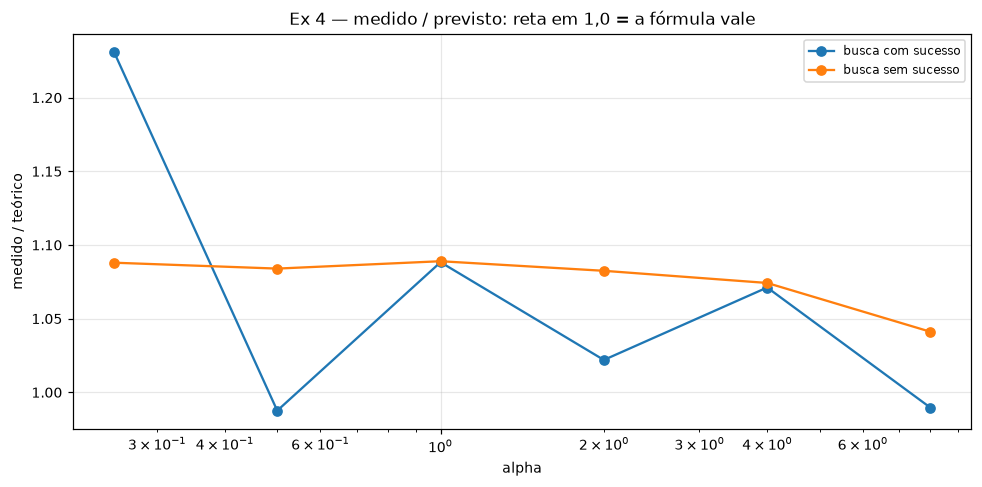


α cresceu 32× (de 0,25 a 8,00) e a razão medido/teórico ficou entre 0.988 e 1.231.
  busca COM sucesso  → 1 + α/2 (percorre em média metade da cadeia)
  busca SEM sucesso  → α       (percorre a cadeia inteira)


In [7]:
grafico_razao(alpha, "alpha", "medido/teorico", "padrao",
              "Ex 4 — medido / previsto: reta em 1,0 = a fórmula vale",
              "ex04_alpha.png", "medido / teórico")
veredito(
    f"α cresceu 32× (de 0,25 a 8,00) e a razão medido/teórico ficou entre "
    f"{alpha['medido/teorico'].min():.3f} e {alpha['medido/teorico'].max():.3f}.\n"
    "  busca COM sucesso  → 1 + α/2 (percorre em média metade da cadeia)\n"
    "  busca SEM sucesso  → α       (percorre a cadeia inteira)"
)

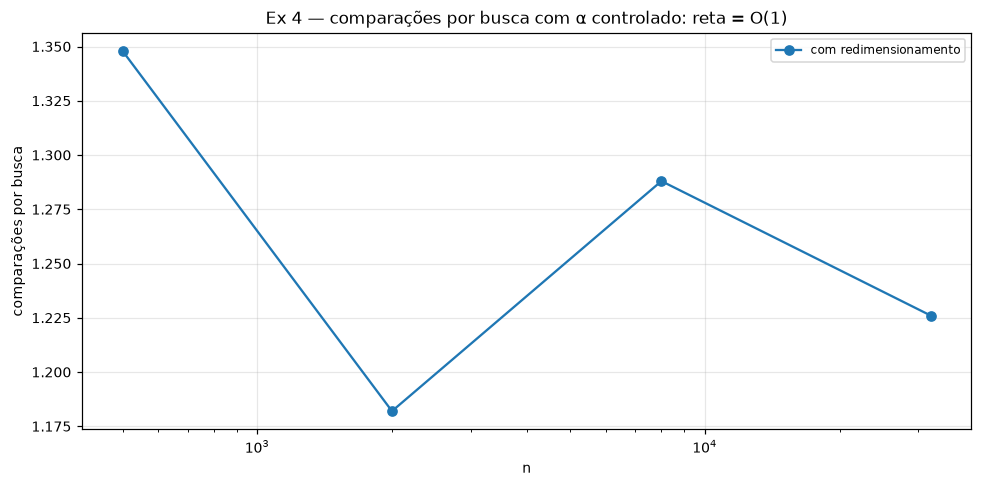

COM REDIMENSIONAMENTO LIGADO, O CUSTO DE BUSCA NÃO CRESCE


,n,capacidade,alpha,comparacoes_por_busca,previsao_teorica,comparacoes_por_busca/n,cadeia_maxima,redimensionamentos,reposicionados/n
0,500,1024,0.4883,1.3480,1.2441,0.0027,3,7,1.5380
1,2000,4096,0.4883,1.1820,1.2441,0.0006,3,9,1.5375
2,8000,16384,0.4883,1.2880,1.2441,0.0002,6,11,1.5366
3,32000,65536,0.4883,1.2260,1.2441,0.0000,4,13,1.5362


In [8]:
com_resize = pd.DataFrame(bench_resizing_keeps_cost_constant())
grafico_razao(com_resize.assign(curva="com redimensionamento"), "n",
              "comparacoes_por_busca", "curva",
              "Ex 4 — comparações por busca com α controlado: reta = O(1)",
              "ex04_resize.png", "comparações por busca")
mostrar(com_resize, ["n", "capacidade", "alpha", "comparacoes_por_busca",
                     "previsao_teorica", "comparacoes_por_busca/n", "cadeia_maxima",
                     "redimensionamentos", "reposicionados/n"],
        "COM REDIMENSIONAMENTO LIGADO, O CUSTO DE BUSCA NÃO CRESCE")

In [9]:
rehash = pd.DataFrame(bench_rehash_amortizado())
mostrar(rehash, ["n", "capacidade", "redimensionamentos", "pares_reposicionados",
                 "reposicionados/n", "copias/n", "comparacoes/n", "tempo_us_por_insercao"],
        "CUSTO AMORTIZADO DO REHASH")
veredito(
    f"n cresceu 1.000× e 'reposicionados/n' ficou entre "
    f"{rehash['reposicionados/n'].min():.2f} e {rehash['reposicionados/n'].max():.2f}.\n"
    "Dobrar a capacidade torna a soma dos rehashes uma série geométrica:\n"
    "  c₀ + 2c₀ + 4c₀ + … < 2n  ⇒  O(1) AMORTIZADO por inserção."
)

CUSTO AMORTIZADO DO REHASH

n cresceu 1.000× e 'reposicionados/n' ficou entre 1.23 e 1.97.
Dobrar a capacidade torna a soma dos rehashes uma série geométrica:
  c₀ + 2c₀ + 4c₀ + … < 2n  ⇒  O(1) AMORTIZADO por inserção.


### Análise em Big O

Com `m` buckets e `n` pares, `α = n/m`:

- busca **bem-sucedida**: `1 + α/2` comparações — percorre em média metade da cadeia;
- busca **mal-sucedida**: `α` comparações — percorre a cadeia inteira;
- como o redimensionamento mantém `α ≤ 0,75`, o termo `1 + α` é **constante** e o
  custo médio é **O(1)**.

A segunda tabela é a prova disso: `n` cresceu 64× (500 → 32.000), α ficou presa
em 0,488 e as comparações por busca não se mexeram (1,18 a 1,35).

Mas **O(1) é uma promessa condicional**, válida só enquanto o hash espalha.

### Caso de borda — o cenário adversarial

In [10]:
adversarial = pd.DataFrame(bench_adversarial())
mostrar(adversarial, ["cenario", "n", "capacidade", "buckets_ocupados", "cadeia_maxima",
                      "alpha", "comparacoes_por_busca", "comparacoes_por_busca/n"],
        "CENÁRIO ADVERSARIAL × BENIGNO")

CENÁRIO ADVERSARIAL × BENIGNO


,cenario,n,capacidade,buckets_ocupados,cadeia_maxima,alpha,comparacoes_por_busca,comparacoes_por_busca/n
0,benigno,50,128,32,3,0.3906,0.6000,0.0120
1,adversarial,50,128,1,50,0.3906,50.0000,1.0000
2,benigno,100,256,90,2,0.3906,0.8800,0.0088
3,adversarial,100,256,1,100,0.3906,100.0000,1.0000
4,benigno,200,512,150,3,0.3906,1.1000,0.0055
5,adversarial,200,512,1,200,0.3906,200.0000,1.0000
6,benigno,400,1024,332,2,0.3906,1.0800,0.0027
7,adversarial,400,1024,1,400,0.3906,400.0000,1.0000


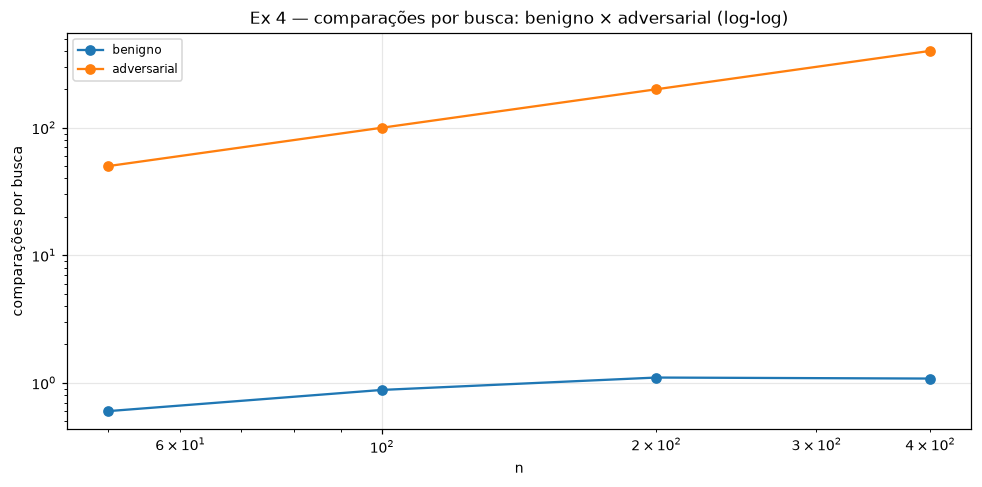


Com n = 400 chaves e capacidade 1024:
  benigno     :  332 buckets ocupados, 1.08 comparações/busca (razão/n = 0.0027)
  adversarial :    1 bucket  ocupado,  400 comparações/busca (razão/n = 1.0000)

A razão EXATAMENTE 1,0000 é a assinatura de Θ(n).
E o detalhe que fecha o argumento: a tabela CRESCEU de 8 para 1.024 buckets
durante o ataque e as chaves continuaram todas juntas — crescer não defende.


In [11]:
grafico_loglog(adversarial, "n", "comparacoes_por_busca", "cenario",
               "Ex 4 — comparações por busca: benigno × adversarial (log-log)",
               "ex04_adversarial.png", "comparações por busca")

pior = adversarial[adversarial["cenario"] == "adversarial"].iloc[-1]
melhor = adversarial[adversarial["cenario"] == "benigno"].iloc[-1]
veredito(
    f"Com n = {int(pior['n'])} chaves e capacidade {int(pior['capacidade'])}:\n"
    f"  benigno     : {int(melhor['buckets_ocupados']):>4} buckets ocupados, "
    f"{melhor['comparacoes_por_busca']:.2f} comparações/busca (razão/n = {melhor['comparacoes_por_busca/n']:.4f})\n"
    f"  adversarial : {int(pior['buckets_ocupados']):>4} bucket  ocupado,  "
    f"{pior['comparacoes_por_busca']:.0f} comparações/busca (razão/n = {pior['comparacoes_por_busca/n']:.4f})\n\n"
    "A razão EXATAMENTE 1,0000 é a assinatura de Θ(n).\n"
    "E o detalhe que fecha o argumento: a tabela CRESCEU de 8 para 1.024 buckets\n"
    "durante o ataque e as chaves continuaram todas juntas — crescer não defende."
)

In [12]:
colidentes = find_colliding_keys(5, modulus=1024)
print("chaves adversariais encontradas por força bruta:", colidentes)
print("resíduo mod 1024:", [default_hash(k) % 1024 for k in colidentes])
for capacidade in (8, 16, 64, 256, 1024):
    print(f"  bucket em capacidade {capacidade:>5}: "
          f"{sorted({default_hash(k) % capacidade for k in colidentes})}")

try:
    HashTableChained().put([1, 2], "valor")
except UnsupportedKeyError as erro:
    print(f"\nUnsupportedKeyError: {erro}")

chaves adversariais encontradas por força bruta: ['adv218', 'adv492', 'adv1088', 'adv1202', 'adv2809']
resíduo mod 1024: [0, 0, 0, 0, 0]
  bucket em capacidade     8: [0]
  bucket em capacidade    16: [0]
  bucket em capacidade    64: [0]
  bucket em capacidade   256: [0]
  bucket em capacidade  1024: [0]

UnsupportedKeyError: tipo de chave não suportado: list. Aceitos: str, bytes, int, bool, None e tuple desses. O motivo é reprodutibilidade: hashear outro tipo exigiria o hash() embutido, que é aleatorizado por processo para str.


**Por que o redimensionamento não defende.** As chaves são escolhidas com hash
congruente módulo 2^k. Como `h₁ ≡ h₂ (mod 2^k)` implica congruência em todo
`2^j` com `j ≤ k`, elas ficam no mesmo bucket **em todas as capacidades** até
`modulus`. A célula acima mostra isso: um único bucket em 8, 16, 64, 256 e 1.024.

**O modelo de ataque.** O adversário controla as chaves inseridas *e* as
consultadas — é assim que um hash flooding funciona. Por isso as sondagens do
cenário adversarial também são chaves colidentes ausentes: uma chave qualquer
cairia num bucket vazio e mediria 0 comparações, descrevendo um ataque que
ninguém faria.